# Experimentos Univariados v4

**Tesis MEC** — Selección reducida y verificada: 32 DGPs × T∈{25,50,100,200} × R=500  
**Horizonte por T:** T=25→H=6 · T=50→H=18 · T=100,200→H=24  
**Métricas:** Bias, Varianza, RMSE, CRPS  
**Bloques:** Corto h=1–6 · Medio h=7–18 · Largo h=19–24  
**Verificación DGP:** cada experimento incluye sección PASS/FAIL antes del Monte Carlo  
**Resultados:** `results/univariate_v4/`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from mectesis.dgp import (
    RandomWalk, SeasonalDGP,
    AR1ARCH, AR1GARCH,
    LocalLevelDGP, LocalTrendDGP,
    ARpDGP, MAqDGP, ARMApqDGP, ARMApqWithTrendDGP,
)
from mectesis.models import (
    ARIMAModel, ARIMAWithTrendModel, SARIMAModel,
    ARARCHModel, ARGARCHModel,
    ETSModel, ThetaModel, ChronosModel,
)
from mectesis.simulation import MonteCarloEngine

SEED    = 3649
H_BY_T  = {25: 6, 50: 18, 100: 24, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [25, 50, 100, 200]
RESULTS = Path("results/univariate_v4")
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

print("Cargando Chronos-2 (puede tardar ~30 s)...")
chronos = ChronosModel(device="cpu")
print("Chronos-2 listo.")

Cargando Chronos-2 (puede tardar ~30 s)...
Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares ────────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, "model", mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns="model").reset_index(drop=True)
        for mname, grp in df.groupby("model", sort=False)
    }


def run_exp(dgp, make_models_fn, dgp_params, exp_id,
            T_list=T_LIST, R_list=R_LIST, H_by_T=None, seed=SEED):
    if H_by_T is None:
        H_by_T = H_BY_T
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    print(f"Exp {exp_id}: {len(T_list)*len(R_list)} ejecución(es) → {combos}")
    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                print(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results(cache)
                continue
            print(f"  T={T} H={h}, R={R}: simulando...", end=" ", flush=True)
            dgp.rng = np.random.default_rng(seed)
            models = make_models_fn(T)
            engine = MonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            print(f"OK ({time.time()-t0:.0f}s)")
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


BLOCK_DEFS = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3 = ["bias", "variance", "rmse", "crps"]


def compute_blocks_v3(results_TR: dict) -> dict:
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        blks = {}
        for blk, h1, h2 in BLOCK_DEFS:
            mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
            blks[blk] = df_h[mask].mean(numeric_only=True)
        out[mname] = blks
    return out


def build_grid_table(all_results: dict, classical_name: str,
                     chronos_name: str = "Chronos-2"):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_v3(res_TR)
        cl_blks  = blk_data.get(classical_name, {})
        ch_blks  = blk_data.get(chronos_name, {})
        for mname, blks in blk_data.items():
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = blks.get(blk, pd.Series(dtype=float))
                for m in METRICS_V3:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["rmse", "crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)
    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def plot_simulation_v3(dgp, models, dgp_params, title="", T_vis=100, seed=SEED):
    H_vis   = H_BY_T.get(T_vis, H_MAX)
    old_rng = dgp.rng
    dgp.rng = np.random.default_rng(seed + 99991)
    y       = dgp.simulate(T=T_vis, **dgp_params)
    dgp.rng = old_rng
    split   = T_vis - H_vis
    y_train = y[:split]
    y_test  = y[split:]
    t_train = np.arange(split)
    t_test  = np.arange(split, T_vis)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(t_train, y_train, color="gray", lw=1.5, label="Histórico")
    ax.axvline(split - 0.5, color="black", ls="--", lw=1, alpha=0.6)
    ax.plot(t_test, y_test, color="black", lw=1.5, marker="o", ms=3, label="Observado")
    palette = ["steelblue", "darkorange", "seagreen", "purple"]
    for i, model in enumerate(models):
        try:
            model.fit(y_train)
            fcst = model.forecast(H_vis)
            c = palette[i % len(palette)]
            ax.plot(t_test, fcst, color=c, lw=1.5, ls="--", marker="s", ms=3, label=model.name)
            if getattr(model, "supports_intervals", False):
                lo, hi = model.forecast_intervals(H_vis, level=0.80)
                ax.fill_between(t_test, lo, hi, color=c, alpha=0.15)
        except Exception as e:
            print(f"  [plot] {model.name} falló: {e}")
    ax.set(title=title, xlabel="t", ylabel="y")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [3]:
# ─── Funciones de verificación DGP ───────────────────────────────────────────

def verify_dgp(label, dgp, dgp_params, classical_model, checks):
    """Valida DGP y estimador. Imprime PASS/FAIL con motivo por cada check."""
    print(f"\n{'─'*60}")
    print(f"VERIFICACIÓN DGP: {label}")
    print(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        y_long = dgp_copy.simulate(T=1000, **dgp_params)
    except Exception as e:
        print(f"  [✗ FAIL] simulate() lanzó excepción: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y_long, dgp, dgp_params, classical_model)
        except Exception as e:
            ok, msg = False, f"excepción inesperada → {e}"
        tag = "✓ PASS" if ok else "✗ FAIL"
        print(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        print(f"  → TODAS LAS VERIFICACIONES PASARON")
    else:
        print(f"  → {n_fail} FALLO(S) — ver detalle arriba")


# ── checks reutilizables ──────────────────────────────────────────────────────

def chk_stationary(y, *_):
    """ADF rechaza raíz unitaria (p < 0.05)."""
    pval = adfuller(y, autolag="AIC")[1]
    return pval < 0.05, f"ADF p={pval:.4f} (umbral 0.05)"

def chk_nonstationary(y, *_):
    """ADF NO rechaza raíz unitaria (p > 0.10) — proceso integrado."""
    pval = adfuller(y, autolag="AIC")[1]
    return pval > 0.10, f"ADF p={pval:.4f} (se espera >0.10)"

def chk_zero_mean(y, *_):
    """Media empírica cercana a 0 (dentro de 3σ/√T)."""
    mu = y.mean(); sigma = y.std(); T = len(y)
    tol = 3.0 * sigma / np.sqrt(T)
    return abs(mu) < tol, f"media={mu:.4f}, tol=±{tol:.4f}"

def chk_acf_lag1(y, dgp, dgp_params, *_):
    """ACF empírica en lag 1 ≈ φ₁ del DGP (tol ±0.15)."""
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    phi1 = props.get("phis", [None])[0] if props.get("phis") else None
    if phi1 is None:
        return True, "no aplica (sin phis)"
    acf_vals = acf(y, nlags=1, fft=True)
    emp = acf_vals[1]
    ok = abs(emp - phi1) < 0.15
    return ok, f"ACF[1]={emp:.4f}, φ₁_DGP={phi1:.4f}, dif={abs(emp-phi1):.4f}"

def chk_ma_cutoff(y, dgp, dgp_params, *_):
    """ACF se anula después del lag q (|ACF[q+1]| < 2/√T)."""
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    thetas = props.get("thetas", [])
    q = len(thetas)
    if q == 0:
        return True, "no aplica (sin thetas)"
    T = len(y)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(y, nlags=q+2, fft=True)
    val_after = abs(acf_vals[q+1])
    ok = val_after < thr
    return ok, f"|ACF[{q+1}]|={val_after:.4f}, umbral=2/√T={thr:.4f}"

def chk_trend_slope(y, dgp, dgp_params, *_):
    """Pendiente OLS ≈ δ del DGP (tol ±0.015)."""
    delta = dgp_params.get("delta", None)
    if delta is None:
        return True, "no aplica (sin delta)"
    T = len(y)
    slope = np.polyfit(np.arange(T), y, 1)[0]
    ok = abs(slope - delta) < 0.015
    return ok, f"pendiente_OLS={slope:.5f}, δ_DGP={delta:.5f}, dif={abs(slope-delta):.5f}"

def chk_arch_effects(y, *_):
    """Ljung-Box sobre y² rechaza independencia (p < 0.05) — efectos ARCH."""
    y2 = y ** 2
    lb = acorr_ljungbox(y2, lags=[10], return_df=True)
    pval = float(lb["lb_pvalue"].iloc[0])
    return pval < 0.05, f"LB(10) sobre y²: p={pval:.4f} (se espera <0.05)"

def chk_rw_variance_growth(y, *_):
    """Varianza crece con t: var(y[T//2:]) > 2 * var(y[:T//4])."""
    T = len(y)
    v1 = np.var(y[:T//4])
    v2 = np.var(y[T//2:])
    ok = v2 > 2.0 * v1
    return ok, f"var(primera cuarta)={v1:.4f}, var(segunda mitad)={v2:.4f}"

def chk_seasonal_acf(y, dgp, dgp_params, *_):
    """ACF en lag s es significativa (>2/√T)."""
    s = dgp_params.get("s", 4)
    T = len(y)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(y, nlags=s+1, fft=True)
    val_s = abs(acf_vals[s])
    ok = val_s > thr
    return ok, f"|ACF[{s}]|={val_s:.4f}, umbral=2/√T={thr:.4f}"

def chk_fit_classical(y, dgp, dgp_params, model):
    """El modelo clásico puede hacer fit+forecast sin error."""
    try:
        m = copy.deepcopy(model)
        m.fit(y[:800])
        fc = m.forecast(horizon=6)
        ok = len(fc) == 6 and not np.any(np.isnan(fc))
        return ok, f"fit+forecast OK, primeros valores: {fc[:3].round(4)}"
    except Exception as e:
        return False, str(e)

def chk_arma_aic(y, dgp, dgp_params, model):
    """AIC de ARMA(p,q) < AIC de AR(p) puro o MA(q) puro."""
    from statsmodels.tsa.arima.model import ARIMA as StatsARIMA
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    p = len(props.get("phis", []))
    q = len(props.get("thetas", []))
    try:
        aic_arma = StatsARIMA(y, order=(p, 0, q)).fit(disp=False).aic
        aic_ar   = StatsARIMA(y, order=(p, 0, 0)).fit(disp=False).aic if p > 0 else np.inf
        aic_ma   = StatsARIMA(y, order=(0, 0, q)).fit(disp=False).aic if q > 0 else np.inf
        baseline = min(aic_ar, aic_ma)
        ok = aic_arma < baseline
        return ok, f"AIC_ARMA={aic_arma:.1f}, AIC_baseline={baseline:.1f}"
    except Exception as e:
        return False, str(e)

def chk_theta_fit(y, dgp, dgp_params, model):
    """ThetaModel se ajusta sin error."""
    try:
        m = copy.deepcopy(model)
        m.fit(y[:800])
        fc = m.forecast(horizon=6)
        return True, f"OK, primeros valores: {fc[:3].round(4)}"
    except Exception as e:
        return False, str(e)

# ── grupos de checks por tipo ─────────────────────────────────────────────────

CHECKS_AR = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("Media ≈ 0",             chk_zero_mean),
    ("ACF[1] ≈ φ₁",          chk_acf_lag1),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_AR_TREND = [
    ("Pendiente OLS ≈ δ",     chk_trend_slope),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_MA = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("Media ≈ 0",             chk_zero_mean),
    ("Corte ACF en lag q",    chk_ma_cutoff),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_MA_TREND = [
    ("Pendiente OLS ≈ δ",     chk_trend_slope),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_ARMA = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("AIC ARMA < baseline",   chk_arma_aic),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_RW = [
    ("No estacionariedad",    chk_nonstationary),
    ("Varianza crece con t",  chk_rw_variance_growth),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_ARCH = [
    ("Estacionariedad media", chk_stationary),
    ("Efectos ARCH (LB y²)",  chk_arch_effects),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_SAR = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("ACF estacional signif.",chk_seasonal_acf),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_ETS = [
    ("No estacionariedad",    chk_nonstationary),
    ("Ajuste modelo clásico", chk_fit_classical),
]
CHECKS_THETA = [
    ("Ajuste Theta",          chk_theta_fit),
]

---
## Bloque A — AR sin tendencia (4 experimentos)

DGPs: AR(1) y AR(4) con baja y alta persistencia  
Modelo clásico: ARIMA(p,0,0) correctamente especificado vs Chronos-2


────────────────────────────────────────────────────────────
VERIFICACIÓN DGP: A.1 — AR(1) baja persist. φ=0.30
────────────────────────────────────────────────────────────
  [✓ PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
  [✓ PASS] Media ≈ 0: media=-0.0366, tol=±0.0973
  [✓ PASS] ACF[1] ≈ φ₁: ACF[1]=0.2880, φ₁_DGP=0.3000, dif=0.0120
  [✓ PASS] Ajuste modelo clásico: fit+forecast OK, primeros valores: [ 0.0908  0.005  -0.0191]
  → TODAS LAS VERIFICACIONES PASARON
Exp A.1: 4 ejecución(es) → (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
  T=25 H=6, R=500: simulando... OK (101s)
  T=50 H=18, R=500: simulando... OK (107s)
  T=100 H=24, R=500: simulando... 

c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OK (168s)
  T=200 H=24, R=500: simulando... OK (216s)

A.1 — AR(1) baja persist. φ=0.30


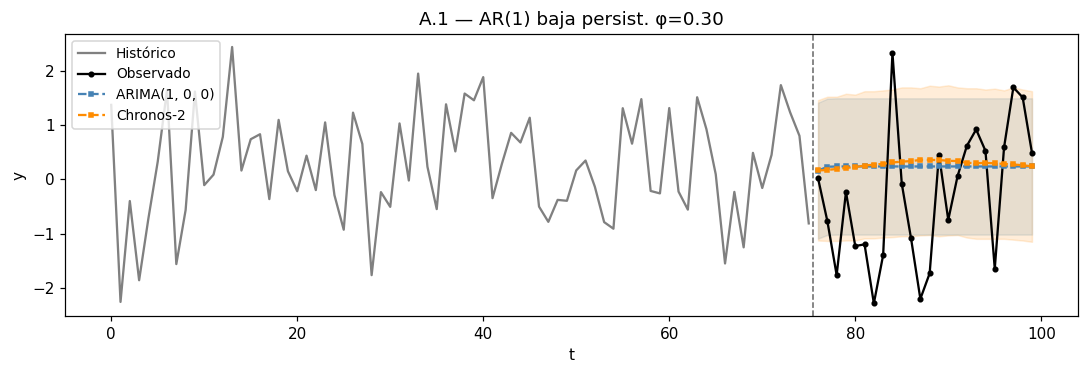

In [4]:
# A.1 — AR(1) baja persist. φ=0.30
cl  = ARIMAModel((1,0,0))
dgp = ARpDGP(phis=[0.30], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("A.1 — AR(1) baja persist. φ=0.30", dgp, dgp_params, cl, CHECKS_AR)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="A.1")
print(f"\n{'='*60}\nA.1 — AR(1) baja persist. φ=0.30\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="A.1 — AR(1) baja persist. φ=0.30")

In [ ]:
# A.2 — AR(1) alta persist. φ=0.90
cl  = ARIMAModel((1,0,0))
dgp = ARpDGP(phis=[0.90], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("A.2 — AR(1) alta persist. φ=0.90", dgp, dgp_params, cl, CHECKS_AR)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="A.2")
print(f"\n{'='*60}\nA.2 — AR(1) alta persist. φ=0.90\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="A.2 — AR(1) alta persist. φ=0.90")

In [ ]:
# A.3 — AR(4) baja persist.
cl  = ARIMAModel((4,0,0))
dgp = ARpDGP(phis=[0.30, 0.10, 0.05, 0.02], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("A.3 — AR(4) baja persist.", dgp, dgp_params, cl, CHECKS_AR)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="A.3")
print(f"\n{'='*60}\nA.3 — AR(4) baja persist.\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="A.3 — AR(4) baja persist.")

In [ ]:
# A.4 — AR(4) alta persist.
cl  = ARIMAModel((4,0,0))
dgp = ARpDGP(phis=[0.90, -0.20, 0.10, -0.05], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("A.4 — AR(4) alta persist.", dgp, dgp_params, cl, CHECKS_AR)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="A.4")
print(f"\n{'='*60}\nA.4 — AR(4) alta persist.\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="A.4 — AR(4) alta persist.")

---
## Bloque B — AR con tendencia determinística (8 experimentos)

Cruce: persistencia {baja=0.30, alta=0.90} × tendencia {baja δ=0.02, alta δ=0.10}  
DGP: `Y_t = δ·t + AR(p)_t`  
Modelo clásico: ARIMAWithTrend (trend='ct')

In [ ]:
# B.1 — AR(1) baja persist. + baja tend. φ=0.30 δ=0.02
cl  = ARIMAWithTrendModel((1, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.1 — AR(1) baja persist. + baja tend. φ=0.30 δ=0.02", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.1")
print(f"\n{'='*60}\nB.1 — AR(1) baja persist. + baja tend. φ=0.30 δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.1 — AR(1) baja persist. + baja tend. φ=0.30 δ=0.02")

In [ ]:
# B.2 — AR(1) baja persist. + alta tend. φ=0.30 δ=0.10
cl  = ARIMAWithTrendModel((1, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.2 — AR(1) baja persist. + alta tend. φ=0.30 δ=0.10", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.2")
print(f"\n{'='*60}\nB.2 — AR(1) baja persist. + alta tend. φ=0.30 δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.2 — AR(1) baja persist. + alta tend. φ=0.30 δ=0.10")

In [ ]:
# B.3 — AR(1) alta persist. + baja tend. φ=0.90 δ=0.02
cl  = ARIMAWithTrendModel((1, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.3 — AR(1) alta persist. + baja tend. φ=0.90 δ=0.02", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.3")
print(f"\n{'='*60}\nB.3 — AR(1) alta persist. + baja tend. φ=0.90 δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.3 — AR(1) alta persist. + baja tend. φ=0.90 δ=0.02")

In [ ]:
# B.4 — AR(1) alta persist. + alta tend. φ=0.90 δ=0.10
cl  = ARIMAWithTrendModel((1, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.4 — AR(1) alta persist. + alta tend. φ=0.90 δ=0.10", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.4")
print(f"\n{'='*60}\nB.4 — AR(1) alta persist. + alta tend. φ=0.90 δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.4 — AR(1) alta persist. + alta tend. φ=0.90 δ=0.10")

In [ ]:
# B.5 — AR(4) baja persist. + baja tend. δ=0.02
cl  = ARIMAWithTrendModel((4, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.5 — AR(4) baja persist. + baja tend. δ=0.02", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.5")
print(f"\n{'='*60}\nB.5 — AR(4) baja persist. + baja tend. δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.5 — AR(4) baja persist. + baja tend. δ=0.02")

In [ ]:
# B.6 — AR(4) baja persist. + alta tend. δ=0.10
cl  = ARIMAWithTrendModel((4, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.6 — AR(4) baja persist. + alta tend. δ=0.10", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.6")
print(f"\n{'='*60}\nB.6 — AR(4) baja persist. + alta tend. δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.6 — AR(4) baja persist. + alta tend. δ=0.10")

In [ ]:
# B.7 — AR(4) alta persist. + baja tend. δ=0.02
cl  = ARIMAWithTrendModel((4, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.7 — AR(4) alta persist. + baja tend. δ=0.02", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.7")
print(f"\n{'='*60}\nB.7 — AR(4) alta persist. + baja tend. δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.7 — AR(4) alta persist. + baja tend. δ=0.02")

In [ ]:
# B.8 — AR(4) alta persist. + alta tend. δ=0.10
cl  = ARIMAWithTrendModel((4, 0, 0), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("B.8 — AR(4) alta persist. + alta tend. δ=0.10", dgp, dgp_params, cl, CHECKS_AR_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="B.8")
print(f"\n{'='*60}\nB.8 — AR(4) alta persist. + alta tend. δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="B.8 — AR(4) alta persist. + alta tend. δ=0.10")

---
## Bloque C — MA sin tendencia (4 experimentos)

DGPs: MA(1) y MA(4) con baja y alta persistencia  
Modelo clásico: ARIMA(0,0,q)

In [ ]:
# C.1 — MA(1) baja persist. θ=0.30
cl  = ARIMAModel((0,0,1))
dgp = MAqDGP(thetas=[0.30], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("C.1 — MA(1) baja persist. θ=0.30", dgp, dgp_params, cl, CHECKS_MA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="C.1")
print(f"\n{'='*60}\nC.1 — MA(1) baja persist. θ=0.30\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="C.1 — MA(1) baja persist. θ=0.30")

In [ ]:
# C.2 — MA(1) alta persist. θ=0.90
cl  = ARIMAModel((0,0,1))
dgp = MAqDGP(thetas=[0.90], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("C.2 — MA(1) alta persist. θ=0.90", dgp, dgp_params, cl, CHECKS_MA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="C.2")
print(f"\n{'='*60}\nC.2 — MA(1) alta persist. θ=0.90\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="C.2 — MA(1) alta persist. θ=0.90")

In [ ]:
# C.3 — MA(4) baja persist.
cl  = ARIMAModel((0,0,4))
dgp = MAqDGP(thetas=[0.30, 0.10, -0.05, 0.02], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("C.3 — MA(4) baja persist.", dgp, dgp_params, cl, CHECKS_MA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="C.3")
print(f"\n{'='*60}\nC.3 — MA(4) baja persist.\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="C.3 — MA(4) baja persist.")

In [ ]:
# C.4 — MA(4) alta persist.
cl  = ARIMAModel((0,0,4))
dgp = MAqDGP(thetas=[0.90, 0.10, -0.05, 0.02], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("C.4 — MA(4) alta persist.", dgp, dgp_params, cl, CHECKS_MA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="C.4")
print(f"\n{'='*60}\nC.4 — MA(4) alta persist.\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="C.4 — MA(4) alta persist.")

---
## Bloque D — MA con tendencia determinística (8 experimentos)

Cruce: persistencia {baja=0.30, alta=0.90} × tendencia {baja δ=0.02, alta δ=0.10}  
Modelo clásico: ARIMAWithTrend (trend='ct')

In [ ]:
# D.1 — MA(1) baja persist. + baja tend. θ=0.30 δ=0.02
cl  = ARIMAWithTrendModel((0, 0, 1), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.1 — MA(1) baja persist. + baja tend. θ=0.30 δ=0.02", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.1")
print(f"\n{'='*60}\nD.1 — MA(1) baja persist. + baja tend. θ=0.30 δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.1 — MA(1) baja persist. + baja tend. θ=0.30 δ=0.02")

In [ ]:
# D.2 — MA(1) baja persist. + alta tend. θ=0.30 δ=0.10
cl  = ARIMAWithTrendModel((0, 0, 1), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.2 — MA(1) baja persist. + alta tend. θ=0.30 δ=0.10", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.2")
print(f"\n{'='*60}\nD.2 — MA(1) baja persist. + alta tend. θ=0.30 δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.2 — MA(1) baja persist. + alta tend. θ=0.30 δ=0.10")

In [ ]:
# D.3 — MA(1) alta persist. + baja tend. θ=0.90 δ=0.02
cl  = ARIMAWithTrendModel((0, 0, 1), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.3 — MA(1) alta persist. + baja tend. θ=0.90 δ=0.02", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.3")
print(f"\n{'='*60}\nD.3 — MA(1) alta persist. + baja tend. θ=0.90 δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.3 — MA(1) alta persist. + baja tend. θ=0.90 δ=0.02")

In [ ]:
# D.4 — MA(1) alta persist. + alta tend. θ=0.90 δ=0.10
cl  = ARIMAWithTrendModel((0, 0, 1), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.4 — MA(1) alta persist. + alta tend. θ=0.90 δ=0.10", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.4")
print(f"\n{'='*60}\nD.4 — MA(1) alta persist. + alta tend. θ=0.90 δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.4 — MA(1) alta persist. + alta tend. θ=0.90 δ=0.10")

In [ ]:
# D.5 — MA(4) baja persist. + baja tend. δ=0.02
cl  = ARIMAWithTrendModel((0, 0, 4), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05, 0.02], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.5 — MA(4) baja persist. + baja tend. δ=0.02", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.5")
print(f"\n{'='*60}\nD.5 — MA(4) baja persist. + baja tend. δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.5 — MA(4) baja persist. + baja tend. δ=0.02")

In [ ]:
# D.6 — MA(4) baja persist. + alta tend. δ=0.10
cl  = ARIMAWithTrendModel((0, 0, 4), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05, 0.02], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.6 — MA(4) baja persist. + alta tend. δ=0.10", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.6")
print(f"\n{'='*60}\nD.6 — MA(4) baja persist. + alta tend. δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.6 — MA(4) baja persist. + alta tend. δ=0.10")

In [ ]:
# D.7 — MA(4) alta persist. + baja tend. δ=0.02
cl  = ARIMAWithTrendModel((0, 0, 4), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05, 0.02], delta=0.02, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.7 — MA(4) alta persist. + baja tend. δ=0.02", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.7")
print(f"\n{'='*60}\nD.7 — MA(4) alta persist. + baja tend. δ=0.02\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.7 — MA(4) alta persist. + baja tend. δ=0.02")

In [ ]:
# D.8 — MA(4) alta persist. + alta tend. δ=0.10
cl  = ARIMAWithTrendModel((0, 0, 4), trend='ct')
dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05, 0.02], delta=0.1, sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("D.8 — MA(4) alta persist. + alta tend. δ=0.10", dgp, dgp_params, cl, CHECKS_MA_TREND)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="D.8")
print(f"\n{'='*60}\nD.8 — MA(4) alta persist. + alta tend. δ=0.10\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="D.8 — MA(4) alta persist. + alta tend. δ=0.10")

---
## Bloque E — ARMA propuesto (2 experimentos)

**E.1 — ARMA(1,1) alta persistencia** φ=0.80, θ=0.40  
Representación parsimoniosa: combinación de memoria AR y corrección MA; típica en índices económicos mensuales.  

**E.2 — ARMA(2,1) moderado** φ=[0.50, 0.20], θ=0.30  
Captura dinámica de ciclo de negocios: AR(2) genera ciclos, MA(1) corrige correlación residual.

In [ ]:
# E.1 — ARMA(1,1) alta persist. φ=0.80 θ=0.40
cl  = ARIMAModel((1,0,1))
dgp = ARMApqDGP(phis=[0.80], thetas=[0.40], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("E.1 — ARMA(1,1) alta persist. φ=0.80 θ=0.40", dgp, dgp_params, cl, CHECKS_ARMA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="E.1")
print(f"\n{'='*60}\nE.1 — ARMA(1,1) alta persist. φ=0.80 θ=0.40\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(1, 0, 1)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="E.1 — ARMA(1,1) alta persist. φ=0.80 θ=0.40")

In [ ]:
# E.2 — ARMA(2,1) moderado φ=[0.50,0.20] θ=0.30
cl  = ARIMAModel((2,0,1))
dgp = ARMApqDGP(phis=[0.50, 0.20], thetas=[0.30], sigma=1.0, seed=SEED)
dgp_params = {}
verify_dgp("E.2 — ARMA(2,1) moderado φ=[0.50,0.20] θ=0.30", dgp, dgp_params, cl, CHECKS_ARMA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="E.2")
print(f"\n{'='*60}\nE.2 — ARMA(2,1) moderado φ=[0.50,0.20] θ=0.30\n{'='*60}")
build_grid_table(res, classical_name="ARIMA(2, 0, 1)")
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="E.2 — ARMA(2,1) moderado φ=[0.50,0.20] θ=0.30")

---
## Bloque F — Random Walk (1 experimento)

DGP: `Y_t = Y_{t-1} + ε_t`  sin drift  
Modelo clásico: ARIMA(0,1,0)

In [ ]:
# F.1 — Random Walk sin drift
cl  = ARIMAModel((0, 1, 0))
dgp = RandomWalk(seed=SEED)
dgp_params = {"drift": 0.0, "sigma": 1.0}
verify_dgp("F.1 — Random Walk sin drift", dgp, dgp_params, cl, CHECKS_RW)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="F.1")
print("\n" + "="*60 + "\nF.1 — Random Walk sin drift\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="F.1 — Random Walk sin drift")

---
## Bloque G — Volatilidad condicional (2 experimentos)

G.1: AR(1)-ARCH(1) α=0.30 — efecto ARCH moderado  
G.2: AR(1)-GARCH(1,1) α+β=0.95 — alta persistencia de varianza  
Modelo clásico: AR+ARCH o AR+GARCH correctamente especificado

In [ ]:
# G.1 — AR(1)-ARCH(1) α=0.30
cl  = ARARCHModel(ar_lags=1, p=1)
dgp = AR1ARCH(seed=SEED)
dgp_params = {"phi": 0.5, "omega": 0.5, "alpha": 0.30}
verify_dgp("G.1 — AR(1)-ARCH(1) α=0.30", dgp, dgp_params, cl, CHECKS_ARCH)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="G.1")
print("\n" + "="*60 + "\nG.1 — AR(1)-ARCH(1) α=0.30\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="G.1 — AR(1)-ARCH(1) α=0.30")

In [ ]:
# G.2 — AR(1)-GARCH(1,1) alta persistencia α+β=0.95
cl  = ARGARCHModel(ar_lags=1, p=1, q=1)
dgp = AR1GARCH(seed=SEED)
dgp_params = {"phi": 0.5, "omega": 0.1, "alpha": 0.10, "beta": 0.85}
verify_dgp("G.2 — AR(1)-GARCH(1,1) α+β=0.95", dgp, dgp_params, cl, CHECKS_ARCH)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="G.2")
print("\n" + "="*60 + "\nG.2 — AR(1)-GARCH(1,1) alta persistencia\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="G.2 — AR(1)-GARCH(1,1) α+β=0.95")

---
## Bloque H — SAR(1)(1)_4 alta persistencia (1 experimento)

DGP: `(1 - 0.90·L)(1 - 0.60·L⁴)Y_t = ε_t`  
Modelo clásico: SARIMA(1,0,0)(1,0,0)_4

In [ ]:
# H.1 — SAR(1)(1)_4 alta persistencia φ=0.90, Φ=0.60
cl  = SARIMAModel(order=(1,0,0), seasonal_order=(1,0,0,4))
dgp = SeasonalDGP(seed=SEED)
dgp_params = {"phi": 0.90, "Phi": 0.60, "s": 4, "sigma": 1.0, "integrated": False}
verify_dgp("H.1 — SAR(1)(1)_4 alta persist.", dgp, dgp_params, cl, CHECKS_SAR)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="H.1")
print("\n" + "="*60 + "\nH.1 — SAR(1)(1)_4 alta persistencia\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="H.1 — SAR(1)(1)_4 φ=0.90 Φ=0.60")

---
## Bloque I — ETS y Theta (2 experimentos)

I.1: Local Level ETS(A,N,N) — nivel estocástico sin tendencia  
I.2: Local Trend → Theta — tendencia suave con componente estocástica

In [ ]:
# I.1 — Local Level ETS(A,N,N)
cl  = ETSModel()
dgp = LocalLevelDGP(seed=SEED)
dgp_params = {"sigma_eps": 1.0, "sigma_eta": 0.10}
verify_dgp("I.1 — Local Level ETS(A,N,N)", dgp, dgp_params, cl, CHECKS_ETS)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="I.1")
print("\n" + "="*60 + "\nI.1 — Local Level ETS(A,N,N)\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="I.1 — Local Level ETS(A,N,N)")

In [ ]:
# I.2 — Theta (DGP: Local Trend σ_ζ=0.05)
cl  = ThetaModel()
dgp = LocalTrendDGP(seed=SEED)
dgp_params = {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.05, "b0": 0.20}
verify_dgp("I.2 — Theta (Local Trend b0=0.20)", dgp, dgp_params, cl, CHECKS_THETA)
res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], dgp_params, exp_id="I.2")
print("\n" + "="*60 + "\nI.2 — Theta (Local Trend)\n" + "="*60)
build_grid_table(res, classical_name=cl.name)
plot_simulation_v3(dgp, [cl, chronos], dgp_params, title="I.2 — Theta (Local Trend b0=0.20)")

---
## Resumen

| Bloque | Descripción | DGPs |
|--------|-------------|------|
| A | AR sin tendencia | 4 |
| B | AR con tendencia (cruce persist.×tend.) | 8 |
| C | MA sin tendencia | 4 |
| D | MA con tendencia (cruce persist.×tend.) | 8 |
| E | ARMA propuesto | 2 |
| F | Random Walk | 1 |
| G | AR+ARCH / AR+GARCH | 2 |
| H | SAR(1)(1)_4 alta persist. | 1 |
| I | ETS(A,N,N) y Theta | 2 |
| **Total** | | **32** |
